In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [14]:
pd.read_csv('customer_churn.csv')

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0
...,...,...,...,...,...,...,...,...,...
495,C00496,50,128,6970,Month-to-month,Credit Card,Yes,1,0
496,C00497,2,49,5917,Two year,Bank Transfer,No,1,0
497,C00498,46,198,2158,Month-to-month,Bank Transfer,No,0,0
498,C00499,1,185,5755,Two year,Credit Card,Yes,1,1


In [15]:
df = pd.read_csv("customer_churn.csv")

print(df.head())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
Rows: 500
Columns: 9


In [16]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB
None
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [17]:
df = df.dropna()

print("Rows after cleaning:", len(df))

Rows after cleaning: 500


In [18]:
encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    if column != "Churn":
        df[column] = encoder.fit_transform(df[column])

In [19]:
df["Churn"] = encoder.fit_transform(df["Churn"])

print(df.head())

   CustomerID  Tenure  MonthlyCharges  TotalCharges  Contract  PaymentMethod  \
0           0       6              64          1540         1              1   
1           1      21             113          1753         0              2   
2           2      27              31          1455         2              1   
3           3      53              29          7150         0              2   
4           4      16             185          1023         1              2   

   PaperlessBilling  SeniorCitizen  Churn  
0                 0              1      0  
1                 1              1      0  
2                 0              1      0  
3                 0              1      0  
4                 0              1      0  


In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:")
print(X.head())

print("Target:")
print(y.head())

Features:
   CustomerID  Tenure  MonthlyCharges  TotalCharges  Contract  PaymentMethod  \
0           0       6              64          1540         1              1   
1           1      21             113          1753         0              2   
2           2      27              31          1455         2              1   
3           3      53              29          7150         0              2   
4           4      16             185          1023         1              2   

   PaperlessBilling  SeniorCitizen  
0                 0              1  
1                 1              1  
2                 0              1  
3                 0              1  
4                 0              1  
Target:
0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 400
Testing data: 100


In [22]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_prediction = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, logistic_prediction))

Logistic Regression Accuracy: 0.95


In [23]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_prediction = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_prediction))

Decision Tree Accuracy: 0.95


In [24]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_prediction = forest_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, forest_prediction))

Random Forest Accuracy: 0.96


In [25]:
models = {
    "Logistic Regression": logistic_prediction,
    "Decision Tree": tree_prediction,
    "Random Forest": forest_prediction
}

for name, prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    print("\n", name)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)


 Logistic Regression
Accuracy : 0.95
Precision: 0.8235294117647058
Recall   : 0.875
F1 Score : 0.8484848484848485

 Decision Tree
Accuracy : 0.95
Precision: 0.8666666666666667
Recall   : 0.8125
F1 Score : 0.8387096774193549

 Random Forest
Accuracy : 0.96
Precision: 1.0
Recall   : 0.75
F1 Score : 0.8571428571428571


[[84  0]
 [ 4 12]]


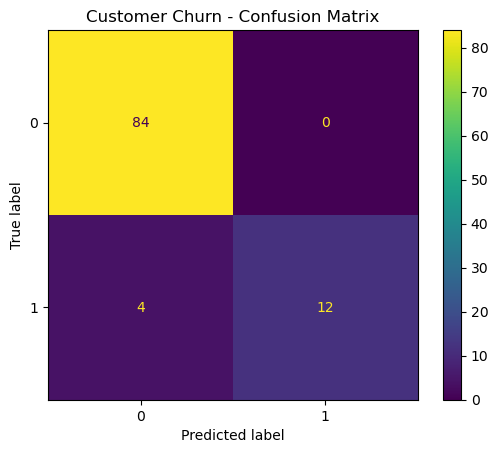

In [26]:
cm = confusion_matrix(y_test, forest_prediction)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Customer Churn - Confusion Matrix")
plt.show()

In [27]:
importance = forest_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
1            Tenure    0.547989
0        CustomerID    0.125206
2    MonthlyCharges    0.119338
4          Contract    0.080643
3      TotalCharges    0.077709
5     PaymentMethod    0.023293
6  PaperlessBilling    0.015497
7     SeniorCitizen    0.010327


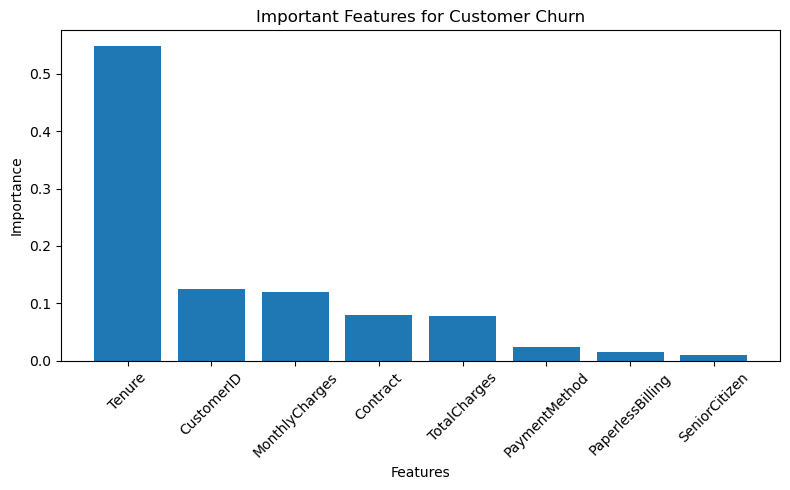

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Important Features for Customer Churn")

plt.tight_layout()
plt.show()

In [29]:
new_customer = X.iloc[[0]]

prediction = forest_model.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is likely to STAY")

Customer is likely to STAY
